In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import LabelEncoder

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries loaded ✓")

Libraries loaded ✓


In [3]:
# Load your parquet file
data_path = "ddos.parquet"

print("Loading dataset...")
df = pd.read_parquet(data_path)

print(f"✓ Loaded {len(df):,} records")
print(f"✓ Total columns: {len(df.columns)}")
print(df.columns)

Loading dataset...
✓ Loaded 540,494 records
✓ Total columns: 34
Index(['bwd_packets_IAT_max', 'bwd_max_header_bytes', 'fwd_mode_header_bytes',
       'syn_flag_percentage_in_total', 'packets_IAT_median',
       'fwd_max_header_bytes', 'packets_IAT_mean', 'rst_flag_counts',
       'bwd_min_header_bytes', 'bwd_packets_IAT_total',
       'fwd_mean_header_bytes', 'bwd_median_header_bytes',
       'bwd_rst_flag_percentage_in_bwd_packets', 'bwd_mode_header_bytes',
       'mean_header_bytes', 'packet_IAT_max', 'fwd_min_header_bytes',
       'min_header_bytes', 'fwd_init_win_bytes', 'packet_IAT_total',
       'fwd_median_header_bytes', 'bwd_rst_flag_counts',
       'bwd_mean_header_bytes', 'mode_header_bytes',
       'ack_flag_percentage_in_total', 'packet_IAT_min', 'max_header_bytes',
       'fwd_syn_flag_percentage_in_total', 'median_header_bytes',
       'packets_IAT_mode', 'bwd_ack_flag_percentage_in_bwd_packets',
       'rst_flag_percentage_in_total', 'label', 'activity'],
      dtype='ob

In [ ]:

# Check both label columns
print("\n=== LABEL (High-level) ===")
print(df['label'].value_counts())

print("\n=== ACTIVITY (Detailed) ===")
print(df['activity'].value_counts())

# Separate features from labels
label_cols = ['label', 'activity']
feature_cols = [col for col in df.columns if col not in label_cols]

X = df[feature_cols]
y_label = df['label']      # For Stage 1
y_activity = df['activity']  # For Stage 2

print(f"\nFeatures: {len(feature_cols)}")
print(f"Feature shape: {X.shape}")


=== LABEL (High-level) ===
label
Benign        349178
Attack        170436
Suspicious     20880
Name: count, dtype: int64

=== ACTIVITY (Detailed) ===
activity
Benign                        301014
Attack-TCP-BYPass-V1          134110
Benign-Web_Browsing_HTTP-S     29376
Suspicious                     20880
Benign-Systemic                 9342
Benign-Telnet                   4766
Attack-TCP-Flag-SYN             3147
Attack-TCP-Flag-ACK             3135
Attack-TCP-Flag-ACK-PSH         3109
Attack-Killer-TCP               3046
Attack-TCP-Valid-SYN            3003
Attack-TCP-Flag-SYN-ACK         2990
Attack-TCP-IGMP                 2960
Attack-TCP-Flag-MIX             2919
Attack-Killall-v2               2824
Attack-TCP-SYN                  2739
Attack-TCP-Control              2491
Benign-SSH                      1968
Benign-Email-Send               1281
Benign-Email-Receive            1084
Attack-TCP-Flag-SYN-TIME         980
Attack-TCP-Flag-SYN-TFO          843
Attack-TCP-Flag-OSYNP    

In [5]:
# Check data types
print("Data types distribution:")
print(X.dtypes.value_counts())

# Numeric vs non-numeric
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\n✓ Numeric features: {len(numeric_features)}")
print(f"✓ Non-numeric features: {len(non_numeric_features)}")

if len(non_numeric_features) > 0:
    print(f"\nNon-numeric features found:")
    print(non_numeric_features[:10])

Data types distribution:
float32    23
int8        8
int32       1
Name: count, dtype: int64

✓ Numeric features: 32
✓ Non-numeric features: 0


Calculating feature importance for BOTH label types...

=== Feature Importance for LABEL Classification ===

Top 20 features for Label classification:
                             Feature  Correlation
17                  min_header_bytes     0.748597
14                 mean_header_bytes     0.737956
23                 mode_header_bytes     0.735449
28               median_header_bytes     0.731927
26                  max_header_bytes     0.714455
16              fwd_min_header_bytes     0.544634
2              fwd_mode_header_bytes     0.544219
20           fwd_median_header_bytes     0.544112
10             fwd_mean_header_bytes     0.544016
5               fwd_max_header_bytes     0.542586
18                fwd_init_win_bytes     0.542291
7                    rst_flag_counts     0.370991
27  fwd_syn_flag_percentage_in_total     0.332576
29                  packets_IAT_mode     0.330695
25                    packet_IAT_min     0.330695
4                 packets_IAT_median     0.330695

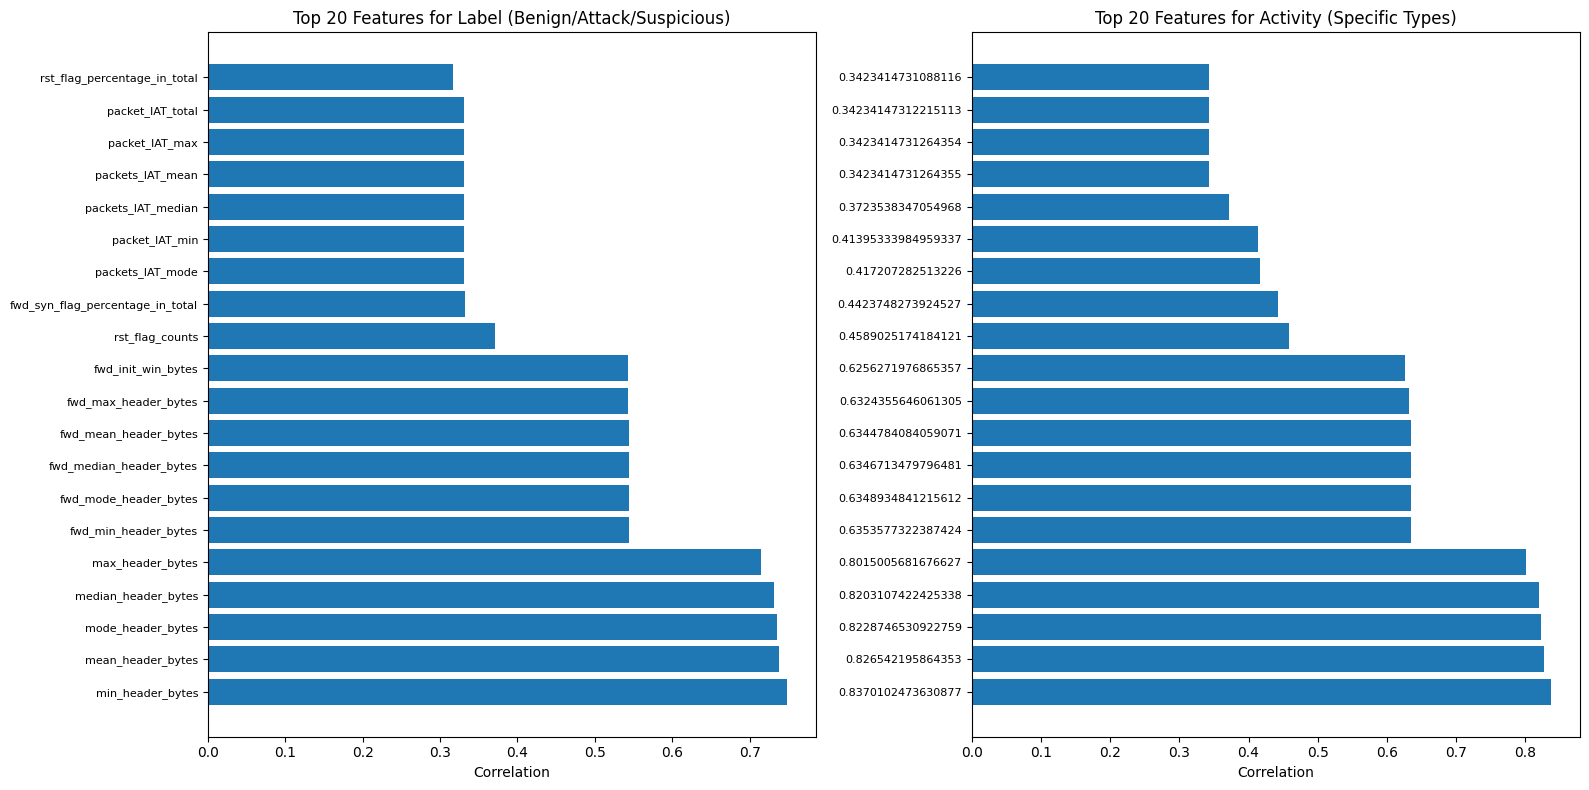

In [6]:
print("Calculating feature importance for BOTH label types...")

# Encode both label types
le_label = LabelEncoder()
le_activity = LabelEncoder()

y_label_encoded = le_label.fit_transform(y_label)
y_activity_encoded = le_activity.fit_transform(y_activity)

# Select numeric features only
X_numeric = X.select_dtypes(include=[np.number])

# Calculate correlations with LABEL (Stage 1: Benign/Attack/Suspicious)
print("\n=== Feature Importance for LABEL Classification ===")
label_correlations = []
for col in X_numeric.columns:
    corr = np.corrcoef(X_numeric[col], y_label_encoded)[0, 1]
    if not np.isnan(corr):
        label_correlations.append((col, abs(corr)))

label_corr_df = pd.DataFrame(label_correlations, columns=['Feature', 'Correlation'])
label_corr_df = label_corr_df.sort_values('Correlation', ascending=False)

print("\nTop 20 features for Label classification:")
print(label_corr_df.head(20))

# Calculate correlations with ACTIVITY (Stage 2: Specific activities)
print("\n=== Feature Importance for ACTIVITY Classification ===")
activity_correlations = []
for col in X_numeric.columns:
    corr = np.corrcoef(X_numeric[col], y_activity_encoded)[0, 1]
    if not np.isnan(corr):
        activity_correlations.append((col, abs(corr)))

activity_corr_df = pd.DataFrame(activity_correlations, columns=['Feature', 'Correlation'])
activity_corr_df = activity_corr_df.sort_values('Correlation', ascending=False)

print("\nTop 20 features for Activity classification:")
print(activity_corr_df.head(20))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Label features
top_20_label = label_corr_df.head(20)
axes[0].barh(range(len(top_20_label)), top_20_label['Correlation'].values)
axes[0].set_yticks(range(len(top_20_label)))
axes[0].set_yticklabels(top_20_label['Feature'].values, fontsize=8)
axes[0].set_xlabel('Correlation')
axes[0].set_title('Top 20 Features for Label (Benign/Attack/Suspicious)')

# Activity features
top_20_activity = activity_corr_df.head(20)
axes[1].barh(range(len(top_20_activity)), top_20_activity['Correlation'].values)
axes[1].set_yticks(range(len(top_20_activity)))
axes[1].set_yticklabels(top_20_activity['Correlation'].values, fontsize=8)
axes[1].set_xlabel('Correlation')
axes[1].set_title('Top 20 Features for Activity (Specific Types)')

plt.tight_layout()
plt.show()

In [7]:
# Strategy: Use union of top features from both tasks
# This ensures we have good features for BOTH stages

n_features_each = 30  # Top 30 from each

# Get top features for each task
top_label_features = set(label_corr_df.head(n_features_each)['Feature'].tolist())
top_activity_features = set(activity_corr_df.head(n_features_each)['Feature'].tolist())

# Union: features good for either task
selected_features = list(top_label_features | top_activity_features)

# Intersection: features good for BOTH tasks
common_features = list(top_label_features & top_activity_features)

print(f"\n=== FEATURE SELECTION RESULTS ===")
print(f"Top features for Label only: {len(top_label_features - top_activity_features)}")
print(f"Top features for Activity only: {len(top_activity_features - top_label_features)}")
print(f"Features good for BOTH: {len(common_features)}")
print(f"Total selected (union): {len(selected_features)}")

print(f"\nFeatures good for BOTH tasks (most valuable):")
for i, feat in enumerate(common_features[:20], 1):
    print(f"{i:2d}. {feat}")

# Create final feature set
X_selected = X[selected_features]

print(f"\nFinal feature set:")
print(f"  Original: {len(X.columns)} features")
print(f"  Selected: {len(selected_features)} features")
print(f"  Reduction: {(1 - len(selected_features)/len(X.columns))*100:.1f}%")


=== FEATURE SELECTION RESULTS ===
Top features for Label only: 2
Top features for Activity only: 2
Features good for BOTH: 28
Total selected (union): 32

Features good for BOTH tasks (most valuable):
 1. bwd_mean_header_bytes
 2. packet_IAT_total
 3. bwd_median_header_bytes
 4. min_header_bytes
 5. packet_IAT_min
 6. fwd_mode_header_bytes
 7. fwd_max_header_bytes
 8. bwd_ack_flag_percentage_in_bwd_packets
 9. bwd_rst_flag_percentage_in_bwd_packets
10. rst_flag_counts
11. packets_IAT_mean
12. syn_flag_percentage_in_total
13. bwd_max_header_bytes
14. max_header_bytes
15. packets_IAT_mode
16. bwd_min_header_bytes
17. mode_header_bytes
18. fwd_init_win_bytes
19. bwd_mode_header_bytes
20. packets_IAT_median

Final feature set:
  Original: 32 features
  Selected: 32 features
  Reduction: 0.0%


In [9]:
import json
# Save feature selection info
feature_info = {
    'n_features_total': len(selected_features),
    'n_features_label_only': len(top_label_features - top_activity_features),
    'n_features_activity_only': len(top_activity_features - top_label_features),
    'n_features_common': len(common_features),
    'selected_features': selected_features,
    'common_features': common_features,
    'label_specific': list(top_label_features - top_activity_features),
    'activity_specific': list(top_activity_features - top_label_features),
    'original_features': len(X.columns),
    'reduction_pct': round((1 - len(selected_features)/len(X.columns))*100, 1)
}

# Save to JSON
with open('selected_features.json', 'w') as f:
    json.dump(feature_info, f, indent=2)

print("✓ Feature info saved to: selected_features.json")

# Save processed data with BOTH labels
processed_data = pd.concat([X_selected, y_label, y_activity], axis=1)
processed_data.to_parquet('ddos.parquet', index=False)

print("✓ Processed data saved to: processed_data.parquet")
print(f"  Shape: {processed_data.shape}")
print(f"  Columns: {len(X_selected.columns)} features + 2 labels")

✓ Feature info saved to: selected_features.json
✓ Processed data saved to: processed_data.parquet
  Shape: (540494, 34)
  Columns: 32 features + 2 labels


In [10]:
print("="*60)
print("DAY 2 COMPLETE - FEATURE EXTRACTION SUMMARY")
print("="*60)

print(f"\nOriginal dataset:")
print(f"  Records: {len(df):,}")
print(f"  Features: {len(X.columns)}")

print(f"\nProcessed dataset:")
print(f"  Records: {len(processed_data):,}")
print(f"  Selected features: {len(selected_features)}")
print(f"  Reduction: {feature_info['reduction_pct']}%")

print(f"\nFeature breakdown:")
print(f"  Good for Label task: {len(top_label_features)}")
print(f"  Good for Activity task: {len(top_activity_features)}")
print(f"  Good for BOTH: {len(common_features)}")

print(f"\nLabel distribution (Stage 1):")
print(y_label.value_counts())

print(f"\nActivity distribution (Stage 2) - Top 10:")
print(y_activity.value_counts().head(10))

print(f"\n✓ Next: Day 3 will build TWO models:")
print(f"  Model 1: Label classifier (Benign/Attack/Suspicious)")
print(f"  Model 2: Activity classifier (Specific types)")

print("\n🎉 Ready for Day 3: Two-Stage Model Training!")
print("="*60)

DAY 2 COMPLETE - FEATURE EXTRACTION SUMMARY

Original dataset:
  Records: 540,494
  Features: 32

Processed dataset:
  Records: 540,494
  Selected features: 32
  Reduction: 0.0%

Feature breakdown:
  Good for Label task: 30
  Good for Activity task: 30
  Good for BOTH: 28

Label distribution (Stage 1):
label
Benign        349178
Attack        170436
Suspicious     20880
Name: count, dtype: int64

Activity distribution (Stage 2) - Top 10:
activity
Benign                        301014
Attack-TCP-BYPass-V1          134110
Benign-Web_Browsing_HTTP-S     29376
Suspicious                     20880
Benign-Systemic                 9342
Benign-Telnet                   4766
Attack-TCP-Flag-SYN             3147
Attack-TCP-Flag-ACK             3135
Attack-TCP-Flag-ACK-PSH         3109
Attack-Killer-TCP               3046
Name: count, dtype: int64

✓ Next: Day 3 will build TWO models:
  Model 1: Label classifier (Benign/Attack/Suspicious)
  Model 2: Activity classifier (Specific types)

🎉 Ready for

# Day 3: CNN-Based IDS with Visual Strip Representation\n\nThis section converts network traffic features into grayscale visual strips and uses a CNN to classify normal vs abnormal traffic.

In [11]:
# Import required libraries for CNN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

# Check GPU details
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        print(f"GPU: {gpu.name}")
else:
    print("Running on CPU")

2026-01-25 17:06:33.047852: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-25 17:06:33.047921: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-25 17:06:33.049493: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-25 17:06:33.058781: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-25 17:06:34.337542: W tensorflow/compiler/tf2

TensorFlow version: 2.15.0
GPU Available: True
GPU: /physical_device:GPU:0


2026-01-25 17:06:35.220011: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-01-25 17:06:35.266587: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-01-25 17:06:35.266907: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [13]:
# Load processed data
df_processed = pd.read_parquet('ddos.parquet')

print(f"Loaded data shape: {df_processed.shape}")
print(f"Columns: {df_processed.columns.tolist()}")

# Separate features and labels
feature_cols = [col for col in df_processed.columns if col not in ['label', 'activity']]
X = df_processed[feature_cols].values
y_label = df_processed['label'].values

print(f"\nFeatures shape: {X.shape}")
print(f"Labels: {np.unique(y_label)}")

Loaded data shape: (540494, 34)
Columns: ['bwd_mean_header_bytes', 'packet_IAT_total', 'bwd_median_header_bytes', 'min_header_bytes', 'packet_IAT_min', 'bwd_packets_IAT_total', 'ack_flag_percentage_in_total', 'fwd_mode_header_bytes', 'fwd_max_header_bytes', 'bwd_packets_IAT_max', 'bwd_rst_flag_counts', 'bwd_ack_flag_percentage_in_bwd_packets', 'bwd_rst_flag_percentage_in_bwd_packets', 'rst_flag_counts', 'packets_IAT_mean', 'syn_flag_percentage_in_total', 'bwd_max_header_bytes', 'max_header_bytes', 'packets_IAT_mode', 'bwd_min_header_bytes', 'mode_header_bytes', 'fwd_init_win_bytes', 'bwd_mode_header_bytes', 'packets_IAT_median', 'fwd_median_header_bytes', 'median_header_bytes', 'packet_IAT_max', 'rst_flag_percentage_in_total', 'mean_header_bytes', 'fwd_min_header_bytes', 'fwd_syn_flag_percentage_in_total', 'fwd_mean_header_bytes', 'label', 'activity']

Features shape: (540494, 32)
Labels: ['Attack' 'Benign' 'Suspicious']


In [14]:
# Convert features to grayscale visual strips (0=black, 255=white, greys in between)
# Each row becomes a 1D strip image where feature values map to pixel intensities

def create_visual_strips(X, strip_width=32, strip_height=8):
    """
    Convert feature vectors to grayscale visual strips.
    
    Parameters:
    - X: Feature matrix (n_samples, n_features)
    - strip_width: Width of each strip (should match n_features or be padded)
    - strip_height: Height of each strip (creates repetition for CNN to learn patterns)
    
    Returns:
    - Visual strips array (n_samples, strip_height, strip_width, 1)
    """
    n_samples, n_features = X.shape
    
    # Normalize features to 0-255 range (grayscale)
    scaler = MinMaxScaler(feature_range=(0, 255))
    X_normalized = scaler.fit_transform(X)
    
    # Pad or truncate to match strip_width
    if n_features < strip_width:
        # Pad with zeros (black)
        padding = np.zeros((n_samples, strip_width - n_features))
        X_normalized = np.hstack([X_normalized, padding])
    elif n_features > strip_width:
        X_normalized = X_normalized[:, :strip_width]
    
    # Create strips by repeating each row to form a 2D image
    # Shape: (n_samples, strip_height, strip_width)
    strips = np.repeat(X_normalized[:, np.newaxis, :], strip_height, axis=1)
    
    # Add channel dimension for CNN (grayscale = 1 channel)
    # Shape: (n_samples, strip_height, strip_width, 1)
    strips = strips[:, :, :, np.newaxis]
    
    return strips.astype(np.float32), scaler

print("Visual strip generator function created")
print(f"Each row will be converted to a {32}x{8} grayscale image")

Visual strip generator function created
Each row will be converted to a 32x8 grayscale image


In [15]:
# Create visual strips from features
STRIP_WIDTH = 32  # Matches our 32 features
STRIP_HEIGHT = 8  # Height of each strip

X_strips, scaler = create_visual_strips(X, strip_width=STRIP_WIDTH, strip_height=STRIP_HEIGHT)

# Normalize to 0-1 range for CNN
X_strips = X_strips / 255.0

print(f"Visual strips shape: {X_strips.shape}")
print(f"Value range: [{X_strips.min():.3f}, {X_strips.max():.3f}]")

Visual strips shape: (540494, 8, 32, 1)
Value range: [0.000, 1.000]


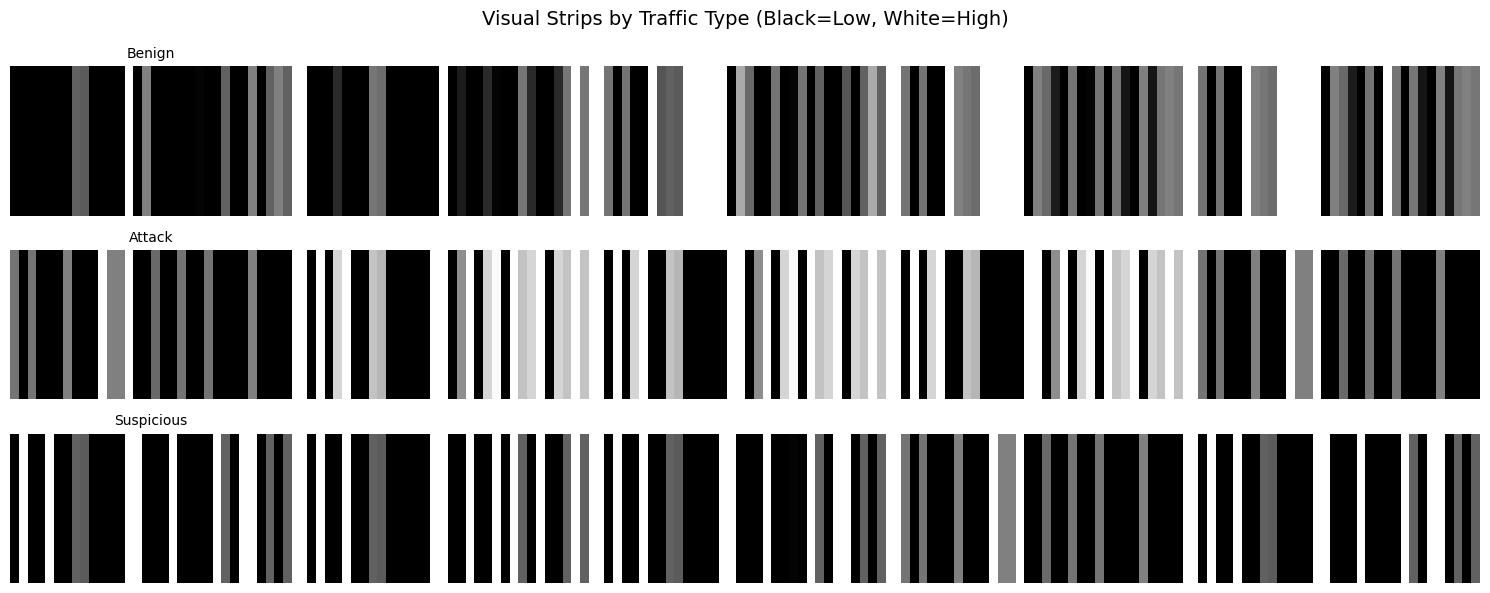

Each strip represents one network traffic record
Features are encoded as pixel intensities (0=black, 1=white)


In [16]:
# Visualize sample strips for each class
fig, axes = plt.subplots(3, 5, figsize=(15, 6))
fig.suptitle('Visual Strips by Traffic Type (Black=Low, White=High)', fontsize=14)

classes = ['Benign', 'Attack', 'Suspicious']
for i, cls in enumerate(classes):
    # Get indices for this class
    cls_indices = np.where(y_label == cls)[0]
    
    # Show 5 random samples
    sample_indices = np.random.choice(cls_indices, min(5, len(cls_indices)), replace=False)
    
    for j, idx in enumerate(sample_indices):
        ax = axes[i, j]
        # Remove channel dimension for display
        strip = X_strips[idx, :, :, 0]
        ax.imshow(strip, cmap='gray', aspect='auto', vmin=0, vmax=1)
        ax.set_title(f'{cls}' if j == 0 else '', fontsize=10)
        ax.axis('off')
    
    axes[i, 0].set_ylabel(cls, fontsize=10, rotation=0, ha='right', va='center')

plt.tight_layout()
plt.show()

print("Each strip represents one network traffic record")
print("Features are encoded as pixel intensities (0=black, 1=white)")

In [18]:
# Encode labels for CNN
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_label)

# Create binary labels: Normal (Benign=0) vs Abnormal (Attack/Suspicious=1)
y_binary = np.where(y_label == 'Benign', 0, 1)

print("Label mappings:")
print(f"  Multi-class: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")
print(f"  Binary: Benign=0 (Normal), Attack/Suspicious=1 (Abnormal)")
print(f"\nBinary distribution:")
print(f"  Normal (0): {np.sum(y_binary == 0):,}")
print(f"  Abnormal (1): {np.sum(y_binary == 1):,}")

Label mappings:
  Multi-class: {'Attack': 0, 'Benign': 1, 'Suspicious': 2}
  Binary: Benign=0 (Normal), Attack/Suspicious=1 (Abnormal)

Binary distribution:
  Normal (0): 349,178
  Abnormal (1): 191,316


In [19]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_strips, y_binary, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_binary
)

# Also split for multi-class
_, _, y_train_multi, y_test_multi = train_test_split(
    X_strips, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")
print(f"\nInput shape for CNN: {X_train.shape[1:]}")

Training set: 432,395 samples
Test set: 108,099 samples

Input shape for CNN: (8, 32, 1)


## CNN Model Architecture\n\nBuilding a CNN that learns patterns from grayscale visual strips to detect network anomalies.

In [20]:
def build_cnn_binary(input_shape):
    """
    Build a CNN for binary classification (Normal vs Abnormal traffic).
    
    Architecture designed for strip-like images where patterns 
    span horizontally across features.
    """
    model = models.Sequential([
        # Input layer
        layers.Input(shape=input_shape),
        
        # First Conv Block - detect local feature patterns
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Second Conv Block - detect higher-level patterns
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Third Conv Block - abstract patterns
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        
        # Dense layers for classification
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        
        # Output layer - binary classification
        layers.Dense(1, activation='sigmoid')
    ])
    
    return model

# Build the model
input_shape = X_train.shape[1:]  # (8, 32, 1)
model_binary = build_cnn_binary(input_shape)

# Compile with binary crossentropy
model_binary.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc'), keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')]
)

model_binary.summary()

2026-01-25 17:12:17.949574: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-01-25 17:12:17.949999: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-01-25 17:12:17.950261: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 8, 32, 32)         320       
                                                                 
 batch_normalization (Batch  (None, 8, 32, 32)         128       
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 8, 32, 32)         9248      
                                                                 
 batch_normalization_1 (Bat  (None, 8, 32, 32)         128       
 chNormalization)                                                
                                                                 
 max_pooling2d (MaxPooling2  (None, 4, 16, 32)         0         
 D)                                                              
                                                        

In [21]:
# Training callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=5,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# Calculate class weights for imbalanced data
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")

Class weights: {0: 0.7739527174574536, 1: 1.4125662352257062}


In [22]:
# Train the CNN model
print("Training CNN for Binary Classification (Normal vs Abnormal)...")
print("="*60)

history = model_binary.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=30,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete!")

Training CNN for Binary Classification (Normal vs Abnormal)...


2026-01-25 17:12:26.946475: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 376355840 exceeds 10% of free system memory.
2026-01-25 17:12:27.328000: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 376355840 exceeds 10% of free system memory.


Epoch 1/30


2026-01-25 17:12:30.071595: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-01-25 17:12:30.462967: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2026-01-25 17:12:34.260552: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fde10516ba0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-25 17:12:34.260620: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): Quadro P5000, Compute Capability 6.1
2026-01-25 17:12:34.267871: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1769361154.399163     125 device_compiler.h:186] Compiled cluster using XLA!  This li

1436/1436 [==============================] - 33s 16ms/step - loss: 0.2123 - accuracy: 0.9271 - auc: 0.9666 - precision: 0.9403 - recall: 0.8478 - val_loss: 0.1905 - val_accuracy: 0.9363 - val_auc: 0.9749 - val_precision: 0.9346 - val_recall: 0.8818 - lr: 0.0010
Epoch 2/30
1436/1436 [==============================] - 23s 16ms/step - loss: 0.1883 - accuracy: 0.9389 - auc: 0.9739 - precision: 0.9480 - recall: 0.8753 - val_loss: 0.1840 - val_accuracy: 0.9394 - val_auc: 0.9755 - val_precision: 0.9506 - val_recall: 0.8743 - lr: 0.0010
Epoch 3/30
1436/1436 [==============================] - 22s 15ms/step - loss: 0.1863 - accuracy: 0.9394 - auc: 0.9744 - precision: 0.9495 - recall: 0.8755 - val_loss: 0.1775 - val_accuracy: 0.9399 - val_auc: 0.9756 - val_precision: 0.9521 - val_recall: 0.8745 - lr: 0.0010
Epoch 4/30
1436/1436 [==============================] - 22s 15ms/step - loss: 0.1849 - accuracy: 0.9396 - auc: 0.9749 - precision: 0.9493 - recall: 0.8760 - val_loss: 0.1725 - val_accuracy: 0.

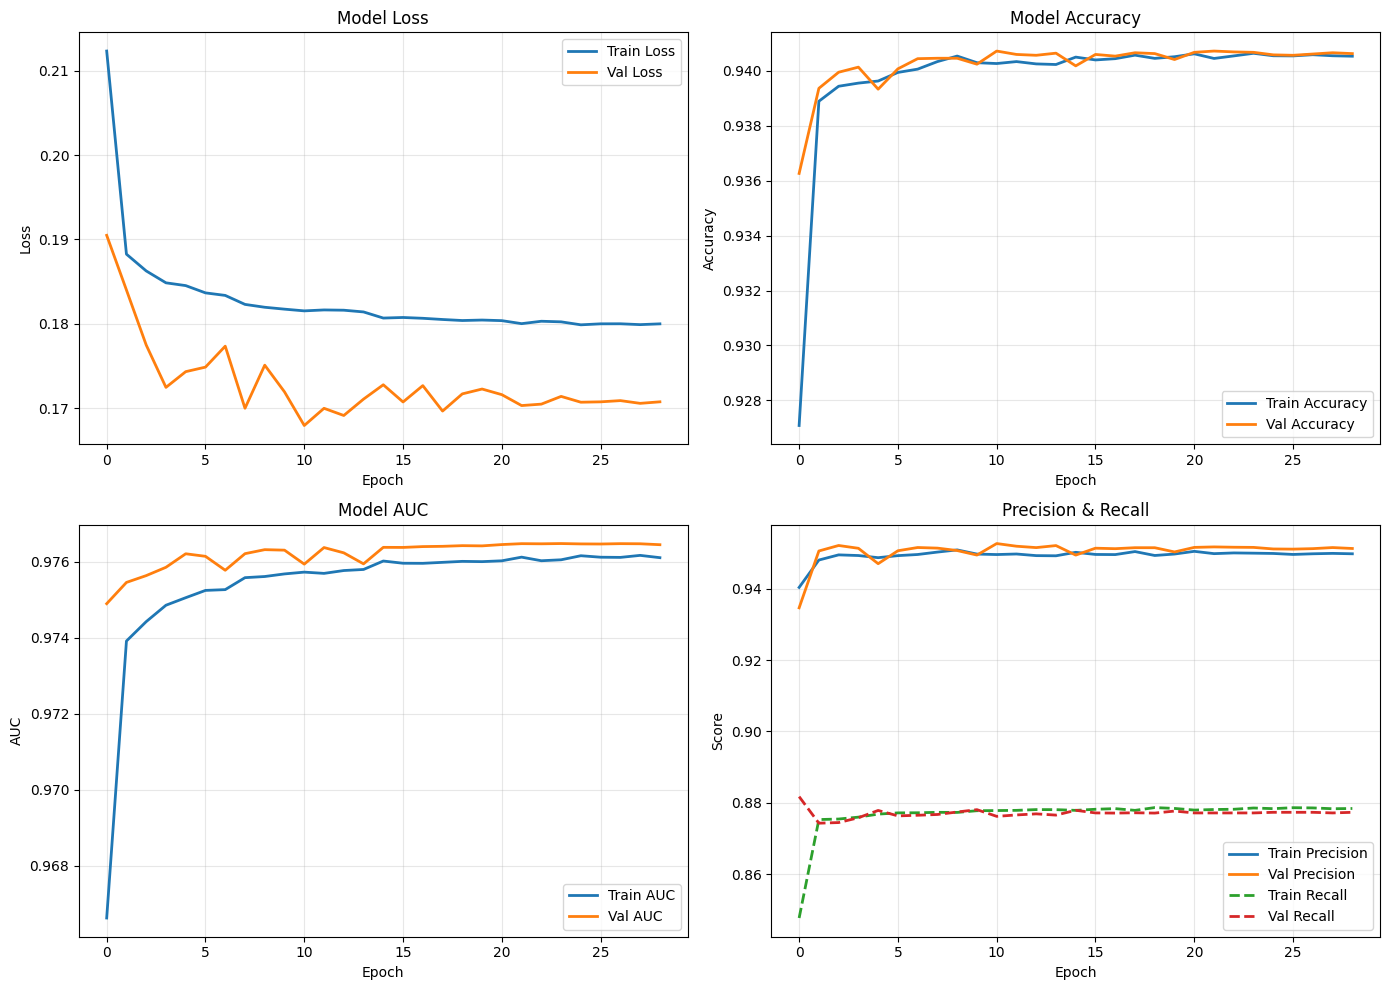

In [23]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_title('Model Loss', fontsize=12)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0, 1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0, 1].set_title('Model Accuracy', fontsize=12)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# AUC
axes[1, 0].plot(history.history['auc'], label='Train AUC', linewidth=2)
axes[1, 0].plot(history.history['val_auc'], label='Val AUC', linewidth=2)
axes[1, 0].set_title('Model AUC', fontsize=12)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUC')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Precision & Recall
axes[1, 1].plot(history.history['precision'], label='Train Precision', linewidth=2)
axes[1, 1].plot(history.history['val_precision'], label='Val Precision', linewidth=2)
axes[1, 1].plot(history.history['recall'], label='Train Recall', linewidth=2, linestyle='--')
axes[1, 1].plot(history.history['val_recall'], label='Val Recall', linewidth=2, linestyle='--')
axes[1, 1].set_title('Precision & Recall', fontsize=12)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Model Evaluation\n\nEvaluate the CNN on the test set and visualize results.

In [24]:
# Evaluate on test set
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

print("Evaluating on Test Set...")
print("="*60)

# Get predictions
y_pred_proba = model_binary.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Test metrics
test_results = model_binary.evaluate(X_test, y_test, verbose=0)
metric_names = model_binary.metrics_names

print("\nTest Set Metrics:")
for name, value in zip(metric_names, test_results):
    print(f"  {name}: {value:.4f}")

Evaluating on Test Set...

Test Set Metrics:
  loss: 0.1721
  accuracy: 0.9405
  auc: 0.9760
  precision: 0.9505
  recall: 0.8776


In [ ]:
# Classification Report
print("\nClassification Report:")
print("="*60)
target_names = ['Normal (Benign)', 'Abnormal (Attack/Suspicious)']
print(classification_report(y_test, y_pred, target_names=target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=target_names, yticklabels=target_names)
axes[0].set_title('Confusion Matrix', fontsize=12)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Normal vs Abnormal Traffic', fontsize=12)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

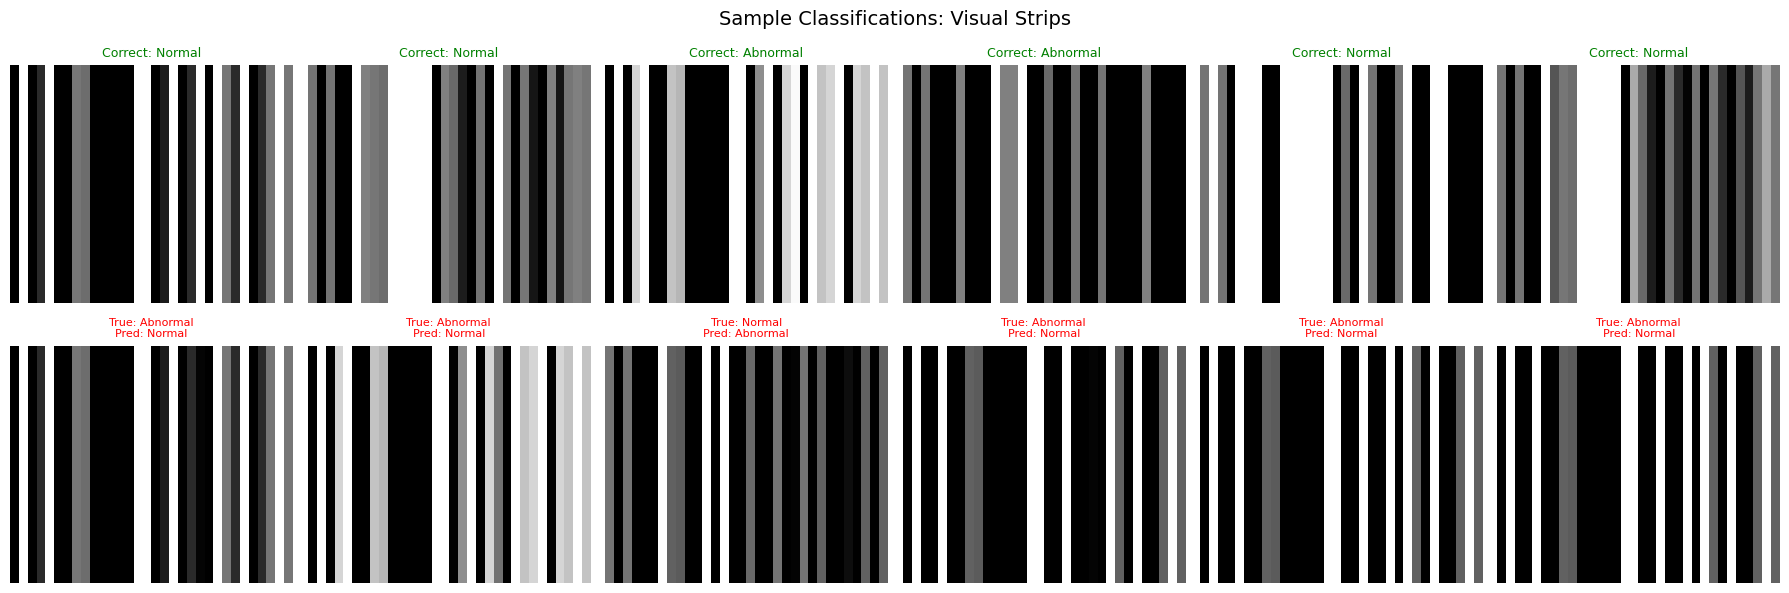


Correctly classified: 101,666 (94.05%)
Incorrectly classified: 6,433 (5.95%)


In [25]:
# Visualize correctly and incorrectly classified samples
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('Sample Classifications: Visual Strips', fontsize=14)

# Correctly classified
correct_mask = y_pred == y_test
correct_indices = np.where(correct_mask)[0]
incorrect_indices = np.where(~correct_mask)[0]

# Show correct classifications
for i in range(min(6, len(correct_indices))):
    idx = correct_indices[i]
    ax = axes[0, i]
    strip = X_test[idx, :, :, 0]
    ax.imshow(strip, cmap='gray', aspect='auto', vmin=0, vmax=1)
    true_label = 'Normal' if y_test[idx] == 0 else 'Abnormal'
    ax.set_title(f'Correct: {true_label}', fontsize=9, color='green')
    ax.axis('off')

axes[0, 0].set_ylabel('Correct', fontsize=10, rotation=0, ha='right', va='center')

# Show incorrect classifications
for i in range(min(6, len(incorrect_indices))):
    idx = incorrect_indices[i]
    ax = axes[1, i]
    strip = X_test[idx, :, :, 0]
    ax.imshow(strip, cmap='gray', aspect='auto', vmin=0, vmax=1)
    true_label = 'Normal' if y_test[idx] == 0 else 'Abnormal'
    pred_label = 'Normal' if y_pred[idx] == 0 else 'Abnormal'
    ax.set_title(f'True: {true_label}\nPred: {pred_label}', fontsize=8, color='red')
    ax.axis('off')

axes[1, 0].set_ylabel('Incorrect', fontsize=10, rotation=0, ha='right', va='center')

plt.tight_layout()
plt.show()

print(f"\nCorrectly classified: {np.sum(correct_mask):,} ({np.sum(correct_mask)/len(y_test)*100:.2f}%)")
print(f"Incorrectly classified: {np.sum(~correct_mask):,} ({np.sum(~correct_mask)/len(y_test)*100:.2f}%)")

## Multi-Class CNN (Benign / Attack / Suspicious)\n\nBuilding a second CNN for 3-class classification.

In [26]:
def build_cnn_multiclass(input_shape, num_classes):
    """
    Build a CNN for multi-class classification (Benign/Attack/Suspicious).
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),
        
        # First Conv Block
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Second Conv Block
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Third Conv Block
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        
        # Dense layers
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        
        # Output layer - multi-class
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Build multi-class model
num_classes = len(label_encoder.classes_)
model_multi = build_cnn_multiclass(input_shape, num_classes)

model_multi.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Multi-class CNN for {num_classes} classes: {list(label_encoder.classes_)}")
model_multi.summary()

Multi-class CNN for 3 classes: ['Attack', 'Benign', 'Suspicious']
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_5 (Conv2D)           (None, 8, 32, 32)         320       
                                                                 
 batch_normalization_6 (Bat  (None, 8, 32, 32)         128       
 chNormalization)                                                
                                                                 
 conv2d_6 (Conv2D)           (None, 8, 32, 32)         9248      
                                                                 
 batch_normalization_7 (Bat  (None, 8, 32, 32)         128       
 chNormalization)                                                
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 4, 16, 32)         0         
 g2D)                                                 

In [27]:
# Calculate class weights for multi-class
class_weights_multi = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_multi),
    y=y_train_multi
)
class_weight_dict_multi = dict(enumerate(class_weights_multi))
print(f"Multi-class weights: {class_weight_dict_multi}")

# Callbacks for multi-class
callbacks_multi = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

# Train multi-class model
print("\nTraining Multi-Class CNN (Benign/Attack/Suspicious)...")
print("="*60)

history_multi = model_multi.fit(
    X_train, y_train_multi,
    validation_split=0.15,
    epochs=30,
    batch_size=256,
    class_weight=class_weight_dict_multi,
    callbacks=callbacks_multi,
    verbose=1
)

print("\nMulti-class training complete!")

Multi-class weights: {0: 1.057079015369872, 1: 0.5159684783049691, 2: 8.62857199872286}

Training Multi-Class CNN (Benign/Attack/Suspicious)...


2026-01-25 17:23:43.192739: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 376355840 exceeds 10% of free system memory.
2026-01-25 17:23:43.575688: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 376355840 exceeds 10% of free system memory.


Epoch 1/30


2026-01-25 17:23:46.337422: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_1/dropout_4/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1436/1436 [==============================] - 24s 14ms/step - loss: 1.1506 - accuracy: 0.3177 - val_loss: 1.0795 - val_accuracy: 0.3177 - lr: 0.0010
Epoch 2/30
1436/1436 [==============================] - 19s 13ms/step - loss: 1.0996 - accuracy: 0.2886 - val_loss: 1.0861 - val_accuracy: 0.4736 - lr: 0.0010
Epoch 3/30
1436/1436 [==============================] - 20s 14ms/step - loss: 1.0991 - accuracy: 0.2996 - val_loss: 1.0949 - val_accuracy: 0.1157 - lr: 0.0010
Epoch 4/30
1433/1436 [============================>.] - ETA: 0s - loss: 1.0988 - accuracy: 0.3020
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1436/1436 [==============================] - 19s 13ms/step - loss: 1.0987 - accuracy: 0.3020 - val_loss: 1.0820 - val_accuracy: 0.3518 - lr: 0.0010
Epoch 5/30
1436/1436 [==============================] - 20s 14ms/step - loss: 1.0982 - accuracy: 0.3136 - val_loss: 1.1045 - val_accuracy: 0.0422 - lr: 5.0000e-04
Epoch 6/30
1436/1436 [===========================

Evaluating Multi-Class Model on Test Set...

Test Loss: 1.0861
Test Accuracy: 0.4716

Classification Report (Multi-Class):
              precision    recall  f1-score   support

      Attack       0.32      0.53      0.39     34087
      Benign       0.65      0.47      0.55     69836
  Suspicious       0.00      0.00      0.00      4176

    accuracy                           0.47    108099
   macro avg       0.32      0.33      0.31    108099
weighted avg       0.52      0.47      0.48    108099



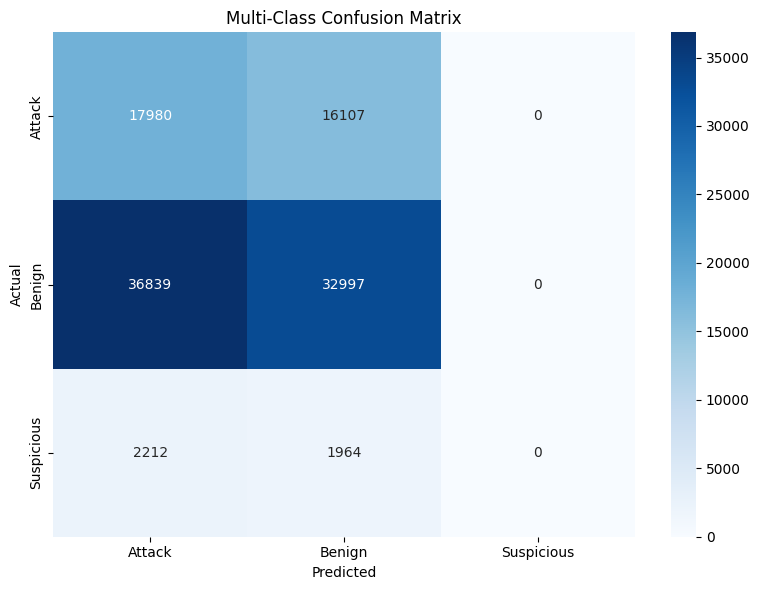

In [28]:
# Evaluate multi-class model
print("Evaluating Multi-Class Model on Test Set...")
print("="*60)

y_pred_multi_proba = model_multi.predict(X_test, verbose=0)
y_pred_multi = np.argmax(y_pred_multi_proba, axis=1)

test_loss_multi, test_acc_multi = model_multi.evaluate(X_test, y_test_multi, verbose=0)
print(f"\nTest Loss: {test_loss_multi:.4f}")
print(f"Test Accuracy: {test_acc_multi:.4f}")

# Classification Report
print("\nClassification Report (Multi-Class):")
print("="*60)
print(classification_report(y_test_multi, y_pred_multi, target_names=label_encoder.classes_))

# Confusion Matrix
cm_multi = confusion_matrix(y_test_multi, y_pred_multi)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Multi-Class Confusion Matrix', fontsize=12)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [29]:
# Save models
import os
os.makedirs('models', exist_ok=True)

model_binary.save('models/cnn_binary_ids.keras')
model_multi.save('models/cnn_multiclass_ids.keras')

# Save the scaler and label encoder
import joblib
joblib.dump(scaler, 'models/feature_scaler.pkl')
joblib.dump(label_encoder, 'models/label_encoder.pkl')

print("Models saved:")
print("  - models/cnn_binary_ids.keras (Normal vs Abnormal)")
print("  - models/cnn_multiclass_ids.keras (Benign/Attack/Suspicious)")
print("  - models/feature_scaler.pkl")
print("  - models/label_encoder.pkl")

Models saved:
  - models/cnn_binary_ids.keras (Normal vs Abnormal)
  - models/cnn_multiclass_ids.keras (Benign/Attack/Suspicious)
  - models/feature_scaler.pkl
  - models/label_encoder.pkl


In [30]:
# Final Summary
print("="*70)
print("CNN-BASED IDS WITH VISUAL STRIP REPRESENTATION - SUMMARY")
print("="*70)

print("\n1. DATA TRANSFORMATION:")
print(f"   - Each traffic record ({len(feature_cols)} features) converted to visual strip")
print(f"   - Strip dimensions: {STRIP_HEIGHT}x{STRIP_WIDTH} pixels (grayscale)")
print(f"   - Feature values mapped to pixel intensities (0=black, 255=white)")

print("\n2. BINARY CLASSIFICATION (Normal vs Abnormal):")
print(f"   - Test Accuracy: {test_results[1]:.4f}")
print(f"   - Test AUC: {roc_auc:.4f}")

print("\n3. MULTI-CLASS CLASSIFICATION (Benign/Attack/Suspicious):")
print(f"   - Test Accuracy: {test_acc_multi:.4f}")

print("\n4. KEY ADVANTAGES OF VISUAL REPRESENTATION:")
print("   - Enables CNN to learn spatial patterns in feature relationships")
print("   - Visual inspection of traffic patterns possible")
print("   - Interpretable: similar traffic types have similar visual patterns")

print("\n5. SAVED ARTIFACTS:")
print("   - models/cnn_binary_ids.keras")
print("   - models/cnn_multiclass_ids.keras")
print("   - models/feature_scaler.pkl")
print("   - models/label_encoder.pkl")

print("\n" + "="*70)
print("Day 3 Complete: CNN IDS Model Training")
print("="*70)

CNN-BASED IDS WITH VISUAL STRIP REPRESENTATION - SUMMARY

1. DATA TRANSFORMATION:
   - Each traffic record (32 features) converted to visual strip
   - Strip dimensions: 8x32 pixels (grayscale)
   - Feature values mapped to pixel intensities (0=black, 255=white)

2. BINARY CLASSIFICATION (Normal vs Abnormal):
   - Test Accuracy: 0.9405


NameError: name 'roc_auc' is not defined